In [1]:
!pip install git+https://github.com/amazon-science/chronos-forecasting.git -q
!pip install statsmodels scikit-learn matplotlib gluonts torch -q
!pip install pytorch-forecasting

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 413.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.4/848.4 kB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 63.8 MB/s eta 0:00:00


In [2]:
import sys
sys.path.insert(0, "/content/chronos-forecasting/src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.forecasting.theta import ThetaModel
from chronos import ChronosPipeline
import torch
import warnings
warnings.filterwarnings('ignore')

In [3]:
url = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset/Train/Hourly-train.csv"
df = pd.read_csv(url)
df = df.set_index('V1').T
df = df.dropna(axis=1, how='all')

print(f"Всего рядов: {df.shape[1]}")
print(f"ID рядов: {df.columns[:5].tolist()}")

Всего рядов: 414
ID рядов: ['H1', 'H2', 'H3', 'H4', 'H5']


In [4]:
def smape(actual, forecast):
    return 100 * np.mean(2 * np.abs(actual - forecast) / (np.abs(actual) + np.abs(forecast) + 1e-8))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=torch.float32,
)

Device: cuda


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

In [5]:
prediction_length = 48
seasonality = 24

chronos_mae = []
chronos_smape = []

snaive_mae = []
snaive_smape = []

ets_mae = []
ets_smape = []

arima_mae = []
arima_smape = []

theta_mae = []
theta_smape = []

In [6]:
all_series_ids = df.columns.tolist()
total = len(all_series_ids)

for idx, series_id in enumerate(all_series_ids):
    series_data = df[series_id].dropna().values

    if len(series_data) < 100:
        continue

    train = series_data[:-prediction_length]
    test = series_data[-prediction_length:]

    try:
        forecast = pipeline.predict(
            torch.tensor(train, dtype=torch.float32),
            prediction_length=prediction_length,
            num_samples=20
        )
        forecast_np = forecast.numpy()
        if forecast_np.ndim == 3:
            forecast_np = forecast_np[0]
        forecast_chronos = np.median(forecast_np, axis=0)
        chronos_mae.append(mean_absolute_error(test, forecast_chronos))
        chronos_smape.append(smape(test, forecast_chronos))
    except:
        pass

    try:
        if len(train) >= seasonality:
            last_season = train[-seasonality:]
            forecast_snaive = np.tile(last_season, (prediction_length // seasonality + 1))[:prediction_length]
            snaive_mae.append(mean_absolute_error(test, forecast_snaive))
            snaive_smape.append(smape(test, forecast_snaive))
    except:
        pass

    try:
        if len(train) > 2 * seasonality:
            model_ets = ExponentialSmoothing(train, seasonal_periods=seasonality, trend=None, seasonal='add')
            fit_ets = model_ets.fit()
            forecast_ets = fit_ets.forecast(prediction_length)
            ets_mae.append(mean_absolute_error(test, forecast_ets))
            ets_smape.append(smape(test, forecast_ets))
    except:
        pass

    try:
        if len(train) > 50:
            model_arima = ARIMA(train, order=(5,1,0))
            fit_arima = model_arima.fit()
            forecast_arima = fit_arima.forecast(prediction_length)
            arima_mae.append(mean_absolute_error(test, forecast_arima))
            arima_smape.append(smape(test, forecast_arima))
    except:
        pass

    try:
        if len(train) > 50:
            model_theta = ThetaModel(train, period=seasonality)
            fit_theta = model_theta.fit()
            forecast_theta = fit_theta.forecast(prediction_length)
            theta_mae.append(mean_absolute_error(test, forecast_theta))
            theta_smape.append(smape(test, forecast_theta))
    except:
        pass

    if (idx + 1) % 50 == 0:
        print(f"Обработано {idx + 1}/{total} рядов")

Обработано 50/414 рядов
Обработано 100/414 рядов
Обработано 150/414 рядов
Обработано 200/414 рядов
Обработано 250/414 рядов
Обработано 300/414 рядов
Обработано 350/414 рядов
Обработано 400/414 рядов


In [7]:
results = []

results.append({
    "Model": "Chronos (zero-shot)",
    "MAE": round(np.mean(chronos_mae), 3),
    "sMAPE": round(np.mean(chronos_smape), 2),
    "n": len(chronos_mae)
})

results.append({
    "Model": "Seasonal Naive",
    "MAE": round(np.mean(snaive_mae), 3),
    "sMAPE": round(np.mean(snaive_smape), 2),
    "n": len(snaive_mae)
})

results.append({
    "Model": "ETS",
    "MAE": round(np.mean(ets_mae), 3),
    "sMAPE": round(np.mean(ets_smape), 2),
    "n": len(ets_mae)
})

results.append({
    "Model": "ARIMA(5,1,0)",
    "MAE": round(np.mean(arima_mae), 3),
    "sMAPE": round(np.mean(arima_smape), 2),
    "n": len(arima_mae)
})

if theta_mae:
    results.append({
        "Model": "Theta",
        "MAE": round(np.mean(theta_mae), 3),
        "sMAPE": round(np.mean(theta_smape), 2),
        "n": len(theta_mae)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('sMAPE')

print(results_df.to_string(index=False))

              Model      MAE  sMAPE   n
Chronos (zero-shot)  376.470   8.49 414
     Seasonal Naive  335.046  14.57 414
                ETS  461.749  16.64 414
              Theta  342.519  19.04 414
       ARIMA(5,1,0) 1271.344  43.99 414


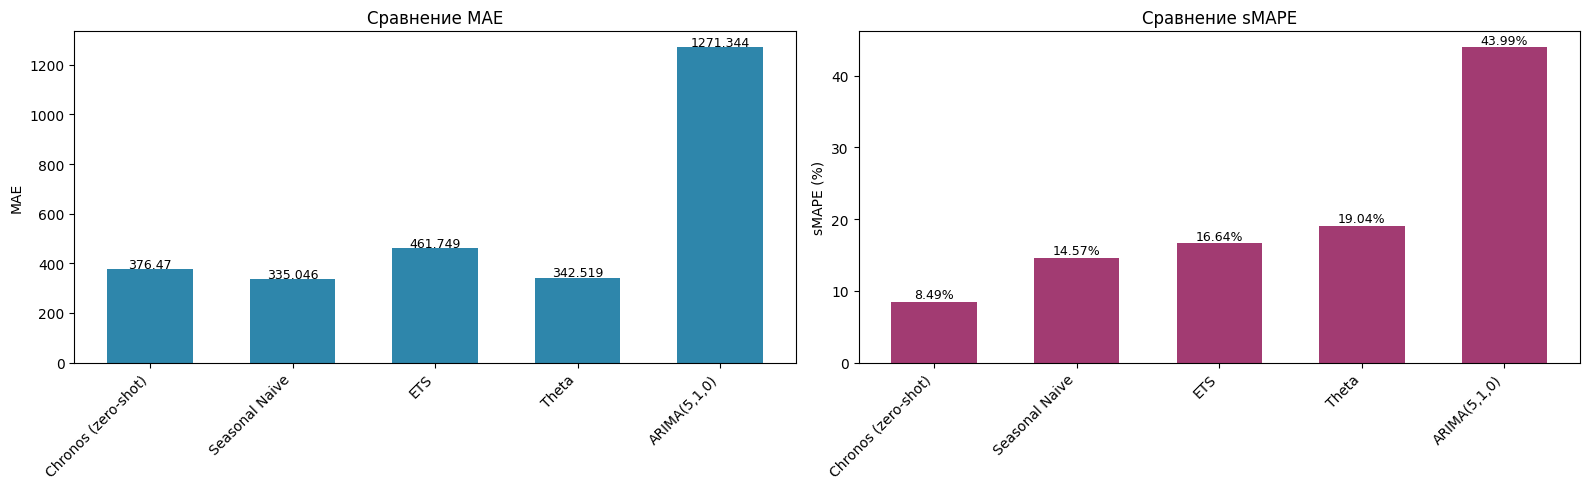

In [8]:
results_df.to_csv("m4_results_extended.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(results_df))
width = 0.6

bars1 = axes[0].bar(x, results_df['MAE'], width, color='#2E86AB')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[0].set_ylabel('MAE')
axes[0].set_title('Сравнение MAE')
for bar, val in zip(bars1, results_df['MAE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontsize=9)

bars2 = axes[1].bar(x, results_df['sMAPE'], width, color='#A23B72')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[1].set_ylabel('sMAPE (%)')
axes[1].set_title('Сравнение sMAPE')
for bar, val in zip(bars2, results_df['sMAPE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val}%", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("m4_results_extended.png", dpi=150)
plt.show()